<a href="https://colab.research.google.com/github/sgevatschnaider/data-science-for-business-models/blob/main/data-science-for-business-models/Missing_Data_en_House_Prices_diagn%C3%B3stico%2C_interpretaci%C3%B3n_e_imputaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title
from IPython.display import display, HTML

html_content = r"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>House Prices: qué es este dataset y por qué es tan útil para estudiar missing data</title>
    <style>
        :root{
            --primary:#1f4e79;
            --secondary:#2e75b6;
            --accent:#eaf3fb;
            --soft:#f7f9fc;
            --text:#2b2b2b;
            --muted:#5b6570;
            --border:#d7e3f1;
            --box:#ffffff;
        }

        body{
            font-family:"Segoe UI", Arial, sans-serif;
            line-height:1.75;
            color:var(--text);
            background:#ffffff;
            margin:0;
            padding:0;
        }

        .container{
            max-width:1180px;
            margin:0 auto;
            padding:30px 28px 60px 28px;
        }

        .hero{
            background:linear-gradient(135deg, #1f4e79 0%, #2e75b6 100%);
            color:white;
            padding:32px 34px;
            border-radius:18px;
            box-shadow:0 8px 24px rgba(31,78,121,0.18);
            margin-bottom:28px;
        }

        .hero h1{
            margin:0 0 10px 0;
            font-size:34px;
            font-weight:700;
        }

        .hero p{
            margin:0;
            font-size:18px;
            opacity:0.97;
        }

        .hero-actions{
            margin-top:20px;
            display:flex;
            justify-content:center;
            flex-wrap:wrap;
            gap:12px;
        }

        .hero-button{
            display:inline-flex;
            align-items:center;
            justify-content:center;
            gap:10px;
            text-decoration:none;
            background:rgba(255,255,255,0.14);
            color:#ffffff;
            border:1px solid rgba(255,255,255,0.28);
            border-radius:999px;
            padding:12px 20px;
            font-size:15px;
            font-weight:600;
            box-shadow:0 4px 12px rgba(0,0,0,0.12);
            transition:all 0.25s ease;
            backdrop-filter:blur(4px);
        }

        .hero-button:hover{
            background:rgba(255,255,255,0.22);
            transform:translateY(-1px);
        }

        h2{
            color:var(--primary);
            margin-top:34px;
            margin-bottom:14px;
            font-size:28px;
            border-bottom:3px solid var(--border);
            padding-bottom:8px;
        }

        h3{
            color:var(--secondary);
            margin-top:26px;
            margin-bottom:10px;
            font-size:22px;
        }

        h4{
            color:var(--primary);
            margin-top:18px;
            margin-bottom:8px;
            font-size:18px;
        }

        p{
            margin:12px 0 14px 0;
            font-size:17px;
        }

        .lead{
            font-size:18px;
        }

        .highlight{
            color:var(--secondary);
            font-weight:700;
        }

        .section-intro{
            background:#f8fbff;
            border:1px solid var(--border);
            border-radius:14px;
            padding:18px 20px;
            margin:18px 0 24px 0;
        }

        .box{
            background:var(--box);
            border:1px solid var(--border);
            border-left:6px solid var(--secondary);
            padding:18px 20px;
            border-radius:14px;
            margin:18px 0;
            box-shadow:0 4px 12px rgba(0,0,0,0.04);
        }

        .soft-box{
            background:var(--soft);
            border:1px solid var(--border);
            padding:18px 20px;
            border-radius:14px;
            margin:16px 0;
        }

        .didactic{
            background:#f9fbfe;
            border:1px dashed #9db7d1;
            padding:16px 18px;
            border-radius:12px;
            margin:18px 0;
        }

        .quote{
            background:#f3f8fd;
            border-left:6px solid var(--secondary);
            padding:18px 20px;
            font-size:18px;
            border-radius:10px;
            margin:22px 0;
            color:#1d3557;
        }

        .callout-green{
            background:#f3fbf0;
            border-left:6px solid #6aa84f;
            padding:16px 18px;
            border-radius:10px;
            margin:18px 0;
        }

        .callout-yellow{
            background:#fff9e8;
            border-left:6px solid #d6b656;
            padding:16px 18px;
            border-radius:10px;
            margin:18px 0;
        }

        .triple-grid{
            display:grid;
            grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
            gap:16px;
            margin:20px 0;
        }

        .mini-card{
            background:white;
            border:1px solid var(--border);
            border-radius:14px;
            padding:18px;
            box-shadow:0 4px 10px rgba(0,0,0,0.03);
        }

        .mini-card h4{
            margin-top:0;
            margin-bottom:8px;
        }

        .example-table{
            width:100%;
            border-collapse:collapse;
            margin-top:16px;
            background:white;
            border-radius:12px;
            overflow:hidden;
        }

        .example-table th, .example-table td{
            border:1px solid var(--border);
            padding:12px 14px;
            text-align:left;
            vertical-align:top;
            font-size:15px;
        }

        .example-table th{
            background:#edf4fb;
            color:var(--primary);
        }

        .mental-map{
            margin:26px 0;
            padding:20px;
            border-radius:16px;
            background:white;
            border:1px solid var(--border);
            box-shadow:0 6px 16px rgba(0,0,0,0.04);
        }

        .caption{
            font-size:14px;
            color:var(--muted);
            margin-top:8px;
        }

        .svg-title{
            font-size:18px;
            font-weight:700;
            fill:#1f4e79;
        }

        .svg-text{
            font-size:14px;
            fill:#2b2b2b;
        }

        .svg-small{
            font-size:13px;
            fill:#415161;
        }

        ul{
            margin:10px 0 14px 24px;
        }

        li{
            margin-bottom:8px;
            font-size:16px;
        }

        code.inline{
            background:#eef5fc;
            border:1px solid var(--border);
            border-radius:6px;
            padding:2px 6px;
            font-size:0.95em;
        }

        .footer{
            margin-top:42px;
            padding-top:18px;
            border-top:2px solid var(--border);
            font-size:14px;
            color:var(--muted);
            text-align:center;
        }

        .two-col{
            display:grid;
            grid-template-columns:1fr 1fr;
            gap:18px;
            align-items:start;
        }

        @media(max-width: 900px){
            .two-col{
                grid-template-columns:1fr;
            }
        }
    </style>
</head>
<body>
<div class="container">

    <div class="hero">
        <h1>House Prices: qué es este dataset y por qué es tan útil para estudiar missing data</h1>
        <p>Un caso ideal para conectar regresión, calidad de datos, interpretación semántica de faltantes y razonamiento económico</p>

        <div class="hero-actions">
            <a class="hero-button" href="https://www.kaggle.com/datasets/yasserh/housing-prices-dataset" target="_blank" rel="noopener noreferrer">
                📊 Ver dataset en Kaggle
            </a>
        </div>
    </div>

    <div class="section-intro">
        <p class="lead">
            El dataset conocido como <span class="highlight">House Prices</span> es la base utilizada en la competencia de Kaggle
            <em>“House Prices: Advanced Regression Techniques”</em>. El objetivo de la competencia es predecir el precio final
            de venta de viviendas residenciales a partir de un conjunto amplio de variables explicativas.
        </p>
        <p>
            Aunque en Kaggle suele verse como una competencia de modelado predictivo, en realidad su valor pedagógico es mucho más amplio:
            sirve para trabajar exploración de datos, ingeniería de variables, tratamiento de variables categóricas, análisis de outliers y,
            de manera especial, <span class="highlight">missing data</span>.
        </p>
    </div>

    <h2>¿Qué es este dataset?</h2>

    <p>
        Kaggle lo presenta como un caso de regresión supervisada con <strong>79 variables explicativas</strong>
        que describen casi todos los aspectos relevantes de una vivienda residencial en Ames, Iowa, Estados Unidos.
        La variable objetivo es <code class="inline">SalePrice</code>, es decir, el precio final de venta de la vivienda en dólares.
    </p>

    <p>
        Sin embargo, más allá del objetivo predictivo, el dataset es especialmente valioso porque contiene faltantes de distinto tipo
        y con distinto significado. Eso lo convierte en un caso excelente para mostrar que los datos ausentes
        <span class="highlight">no deben interpretarse automáticamente como error o simple omisión</span>.
    </p>

    <div class="quote">
        House Prices es tan útil para estudiar missing data porque obliga a enseñar que antes de imputar un faltante hay que interpretarlo.
    </div>

    <div class="triple-grid">
        <div class="mini-card">
            <h4>Problema intuitivo</h4>
            <p>Las variables son fáciles de comprender: tamaño, antigüedad, calidad, garage, sótano, pileta, ubicación y precio.</p>
        </div>
        <div class="mini-card">
            <h4>Alta riqueza descriptiva</h4>
            <p>Combina variables nominales, ordinales, discretas y continuas, con gran valor para estadística y machine learning.</p>
        </div>
        <div class="mini-card">
            <h4>Excelente para missing data</h4>
            <p>Los faltantes no son homogéneos: algunos indican ausencia real del atributo y otros sí pueden ser omisiones o no observación.</p>
        </div>
    </div>

    <h2>De dónde provienen los datos</h2>

    <p>
        La base no fue creada originalmente por Kaggle. Proviene del conocido
        <span class="highlight">Ames Housing Dataset</span>, compilado por <strong>Dean De Cock</strong>
        como alternativa más rica y realista al clásico dataset de Boston Housing.
    </p>

    <p>
        En su artículo de 2011, De Cock explica que el conjunto de datos describe la venta de propiedades residenciales individuales
        en Ames, Iowa, entre <strong>2006 y 2010</strong>. El dataset original contiene <strong>2930 observaciones</strong>
        y una gran cantidad de variables explicativas asociadas a la valuación y a las características físicas,
        funcionales y de localización de las propiedades.
    </p>

    <div class="soft-box">
        <strong>Origen institucional del dataset:</strong>
        <ul>
            <li>la información proviene del <em>Ames Assessor’s Office</em>,</li>
            <li>es decir, la oficina de catastro o valuación del municipio,</li>
            <li>que utiliza estos datos para calcular valores fiscales y registrar características de las propiedades.</li>
        </ul>
    </div>

    <p>
        Esto es importante porque muestra que no se trata de una base artificial creada desde cero para enseñanza,
        sino de un conjunto derivado de <span class="highlight">registros administrativos y de valuación inmobiliaria reales</span>.
    </p>

    <h2>Qué tipo de información contiene</h2>

    <p>
        El dataset reúne variables que describen múltiples dimensiones de una vivienda. Incluye, entre otras,
        características del lote, zonificación, tipo de construcción, calidad general, condición general,
        año de construcción, superficie habitable, superficie de sótano, cantidad de baños, cantidad de habitaciones,
        presencia o no de cochera, pileta, chimenea, terraza de madera, cercanía a determinadas infraestructuras
        y muchas otras variables estructurales o de contexto.
    </p>

    <div class="didactic">
        <strong>En términos pedagógicos, esto permite trabajar:</strong>
        <ul>
            <li>variables numéricas continuas y discretas,</li>
            <li>variables categóricas nominales y ordinales,</li>
            <li>relaciones entre atributos físicos y valor económico,</li>
            <li>outliers, asimetrías y escalas heterogéneas,</li>
            <li>y múltiples patrones de datos faltantes.</li>
        </ul>
    </div>

    <p>
        El artículo original de De Cock señala además que el dataset fue diseñado justamente para ofrecer una estructura
        mucho más rica que otros conjuntos clásicos usados en enseñanza de regresión.
        Por eso resulta especialmente útil para cursos de estadística, econometría aplicada,
        machine learning y ciencia de datos.
    </p>

    <h2>Cómo aparece en Kaggle</h2>

    <p>
        En Kaggle, el dataset se ofrece en una versión preparada para competencia.
        Allí se divide principalmente en archivos como <code class="inline">train.csv</code> y <code class="inline">test.csv</code>,
        junto con un archivo de descripción de variables.
    </p>

    <div class="two-col">
        <div class="box">
            <h3>Conjunto de entrenamiento</h3>
            <p>
                El archivo <code class="inline">train.csv</code> incluye la variable objetivo
                <code class="inline">SalePrice</code>, por lo que sirve para entrenar modelos,
                explorar relaciones y estudiar el vínculo entre atributos y precio.
            </p>
        </div>

        <div class="box">
            <h3>Conjunto de prueba</h3>
            <p>
                El archivo <code class="inline">test.csv</code> no incluye <code class="inline">SalePrice</code>,
                justamente porque esa variable debe ser predicha por los participantes de la competencia.
            </p>
        </div>
    </div>

    <p>
        Esta estructura lo vuelve ideal para enseñar flujo completo de modelado:
        <span class="highlight">exploración, limpieza, tratamiento de faltantes, transformación de variables, entrenamiento y predicción</span>.
    </p>

    <p>
        Además, Kaggle presenta este caso como una competencia de práctica para trabajar técnicas de regresión,
        <em>feature engineering</em>, random forests y gradient boosting. Pero desde un punto de vista docente,
        uno de sus mayores atractivos es que las variables tienen significado interpretable,
        algo que facilita mucho la explicación en clase.
    </p>

    <h2>Por qué es tan bueno para explicar missing data</h2>

    <p>
        Este dataset es especialmente valioso para enseñar missing data porque los faltantes
        <span class="highlight">no son homogéneos</span>. En varias variables, la ausencia no significa necesariamente que el dato se perdió
        o no se cargó, sino que el atributo no existe en esa vivienda.
    </p>

    <p>
        Por ejemplo, si una casa no tiene pileta, entonces ciertas variables vinculadas a la pileta aparecen vacías
        no porque falte información, sino porque esa característica no aplica al caso.
        La misma lógica aparece con atributos como ciertos tipos de sótano, garaje, chimenea, cercos o elementos exteriores.
    </p>

    <div class="callout-yellow">
        <strong>Valor didáctico central:</strong> House Prices permite trabajar muy bien la diferencia entre
        <span class="highlight">missing estructural</span> y <span class="highlight">missing por omisión o falla de registro</span>.
    </div>

    <p>
        Justamente por eso House Prices es tan didáctico: obliga a enseñar que antes de imputar un faltante
        hay que interpretarlo semánticamente. No alcanza con ver un <code class="inline">NaN</code> y reemplazarlo por media,
        moda o mediana. Primero hay que preguntarse si ese vacío representa:
    </p>

    <div class="soft-box">
        <ul>
            <li>una ausencia real del atributo,</li>
            <li>una no respuesta,</li>
            <li>una falla de integración,</li>
            <li>o un dato no observado.</li>
        </ul>
    </div>

    <p>
        Desde una perspectiva de clase, este punto es ideal porque conecta
        <span class="highlight">estadística, conocimiento del dominio y calidad de datos</span>.
    </p>

    <h2>Valor pedagógico y analítico</h2>

    <p>
        Desde el punto de vista pedagógico, House Prices tiene varias ventajas.
        El problema es intuitivo, porque casi cualquier estudiante entiende qué significa una vivienda,
        su tamaño, antigüedad o calidad constructiva.
    </p>

    <p>
        A la vez, el dataset es lo suficientemente rico como para mostrar problemas reales de análisis de datos:
        variables categóricas con muchas categorías, escalas heterogéneas, asimetrías en distribuciones,
        outliers y patrones diversos de datos faltantes.
        Eso permite que el caso no se limite a una simple práctica de código,
        sino que funcione como ejemplo integral de razonamiento estadístico y analítico.
    </p>

    <div class="callout-green">
        <strong>Lectura para Economía Empresarial:</strong> House Prices muestra que la información observada sobre un activo
        nunca es completamente neutra ni perfecta. La empresa o el analista toma decisiones con información parcial,
        heterogénea y a veces ambigua.
    </div>

    <p>
        En ese sentido, House Prices no solo ilustra regresión, sino también problemas de
        <span class="highlight">representación incompleta de la realidad</span>,
        que es justamente el corazón del estudio de missing data.
    </p>

    <h2>Mapa conceptual del caso</h2>

    <div class="mental-map">
        <svg viewBox="0 0 1140 640" width="100%" height="auto">
            <text x="570" y="42" text-anchor="middle" class="svg-title">Por qué House Prices es tan útil para estudiar missing data</text>

            <rect x="430" y="75" rx="18" ry="18" width="280" height="58" fill="#eaf3fb" stroke="#2e75b6" stroke-width="2"/>
            <text x="570" y="110" text-anchor="middle" class="svg-text" font-weight="700">House Prices / Ames Housing</text>

            <line x1="570" y1="133" x2="570" y2="190" stroke="#7aa6d1" stroke-width="3"/>
            <polygon points="570,190 563,178 577,178" fill="#7aa6d1"/>

            <rect x="330" y="190" rx="16" ry="16" width="480" height="62" fill="#f7f9fc" stroke="#2e75b6" stroke-width="2"/>
            <text x="570" y="217" text-anchor="middle" class="svg-text" font-weight="700">Dataset real, rico e interpretable</text>
            <text x="570" y="239" text-anchor="middle" class="svg-small">problema intuitivo + variedad de variables + faltantes con significados distintos</text>

            <line x1="570" y1="252" x2="130" y2="355" stroke="#7aa6d1" stroke-width="3"/>
            <line x1="570" y1="252" x2="350" y2="355" stroke="#7aa6d1" stroke-width="3"/>
            <line x1="570" y1="252" x2="570" y2="355" stroke="#7aa6d1" stroke-width="3"/>
            <line x1="570" y1="252" x2="790" y2="355" stroke="#7aa6d1" stroke-width="3"/>
            <line x1="570" y1="252" x2="1010" y2="355" stroke="#7aa6d1" stroke-width="3"/>

            <rect x="30" y="355" rx="16" ry="16" width="200" height="82" fill="#ffffff" stroke="#bfd4e8"/>
            <text x="130" y="382" text-anchor="middle" class="svg-text" font-weight="700">Origen real</text>
            <text x="130" y="406" text-anchor="middle" class="svg-small">registros administrativos del Ames Assessor’s Office</text>

            <rect x="250" y="355" rx="16" ry="16" width="200" height="82" fill="#ffffff" stroke="#bfd4e8"/>
            <text x="350" y="382" text-anchor="middle" class="svg-text" font-weight="700">Problema intuitivo</text>
            <text x="350" y="406" text-anchor="middle" class="svg-small">viviendas, atributos físicos y precio de venta</text>

            <rect x="470" y="355" rx="16" ry="16" width="200" height="82" fill="#ffffff" stroke="#bfd4e8"/>
            <text x="570" y="382" text-anchor="middle" class="svg-text" font-weight="700">Riqueza estadística</text>
            <text x="570" y="406" text-anchor="middle" class="svg-small">variables nominales, ordinales, discretas y continuas</text>

            <rect x="690" y="355" rx="16" ry="16" width="200" height="82" fill="#ffffff" stroke="#bfd4e8"/>
            <text x="790" y="382" text-anchor="middle" class="svg-text" font-weight="700">Missing no homogéneo</text>
            <text x="790" y="406" text-anchor="middle" class="svg-small">algunas ausencias significan “no aplica”</text>

            <rect x="910" y="355" rx="16" ry="16" width="200" height="82" fill="#ffffff" stroke="#bfd4e8"/>
            <text x="1010" y="382" text-anchor="middle" class="svg-text" font-weight="700">Valor docente</text>
            <text x="1010" y="406" text-anchor="middle" class="svg-small">ideal para enseñar interpretación antes de imputación</text>

            <rect x="250" y="520" rx="14" ry="14" width="640" height="78" fill="#ffffff" stroke="#bfd4e8"/>
            <text x="570" y="550" text-anchor="middle" class="svg-text" font-weight="700">Idea final</text>
            <text x="570" y="574" text-anchor="middle" class="svg-small">House Prices permite enseñar que un NaN no debe tratarse automáticamente: primero debe entenderse qué significa en el dominio del problema</text>
        </svg>
        <div class="caption">
            House Prices combina realismo, interpretabilidad y riqueza estructural, por eso funciona tan bien como caso para enseñar missing data.
        </div>
    </div>

    <h2>Síntesis rápida del caso</h2>

    <table class="example-table">
        <thead>
            <tr>
                <th>Aspecto</th>
                <th>Qué aporta el dataset</th>
                <th>Valor para missing data</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Origen</td>
                <td>Base derivada de registros administrativos reales</td>
                <td>Permite discutir calidad de datos en contextos no artificiales</td>
            </tr>
            <tr>
                <td>Problema</td>
                <td>Predicción del precio de venta de viviendas</td>
                <td>Conecta atributos observados con una decisión económica clara: la valuación</td>
            </tr>
            <tr>
                <td>Variables</td>
                <td>79 variables explicativas con distintos tipos y significados</td>
                <td>Ideal para mostrar heterogeneidad y complejidad del dato</td>
            </tr>
            <tr>
                <td>Faltantes</td>
                <td>No todos tienen el mismo significado</td>
                <td>Permite distinguir entre ausencia estructural, omisión y no observación</td>
            </tr>
            <tr>
                <td>Uso docente</td>
                <td>Sirve para EDA, regresión, ingeniería de variables y calidad de datos</td>
                <td>Excelente para enseñar que primero se interpreta y después se imputa</td>
            </tr>
        </tbody>
    </table>

    <h2>Texto breve de cierre para tu Colab</h2>

    <div class="box">
        <p>
            House Prices es un dataset de Kaggle basado en el Ames Housing Dataset, compilado por Dean De Cock a partir
            de registros del Ames Assessor’s Office sobre propiedades residenciales vendidas en Ames, Iowa, entre 2006 y 2010.
            La base original contiene información detallada sobre miles de viviendas y fue adaptada en Kaggle como un problema
            de regresión para predecir el precio de venta. Su riqueza descriptiva, la diversidad de tipos de variables
            y la presencia de faltantes con distintos significados lo convierten en un caso excelente para estudiar missing data,
            no solo como problema técnico de imputación, sino como fenómeno de interpretación, calidad de datos y toma de decisiones.
        </p>
    </div>

    <div class="footer">
        Material de Cátedra — Profesor Sergio Gevatschnaider
    </div>

</div>
</body>
</html>
"""

display(HTML(html_content))

Aspecto,Qué aporta el dataset,Valor para missing data
Origen,Base derivada de registros administrativos reales,Permite discutir calidad de datos en contextos no artificiales
Problema,Predicción del precio de venta de viviendas,Conecta atributos observados con una decisión económica clara: la valuación
Variables,79 variables explicativas con distintos tipos y significados,Ideal para mostrar heterogeneidad y complejidad del dato
Faltantes,No todos tienen el mismo significado,"Permite distinguir entre ausencia estructural, omisión y no observación"
Uso docente,"Sirve para EDA, regresión, ingeniería de variables y calidad de datos",Excelente para enseñar que primero se interpreta y después se imputa


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 17.6 MB/s eta 0:00:00
Nombre del dataset: house_prices
Dimensiones del dataset: (1460, 81)

Primeras filas:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
Street,1460,2,Pave,1454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,91,2,Grvl,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1460,4,Reg,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1460,4,Lvl,1311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1460,2,AllPub,1459,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dimensiones de X: (1460, 80)
Dimensiones de y: (1460,)

Total de valores faltantes: 6965
Total de celdas del dataset: 116800
Porcentaje global de missing data: 5.96%

Variables con faltantes:


,missing_count,missing_pct,dtype
PoolQC,1453,99.520548,object
MiscFeature,1406,96.301370,object
Alley,1369,93.767123,object
Fence,1179,80.753425,object
FireplaceQu,690,47.260274,object
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,object
GarageYrBlt,81,5.547945,float64
GarageQual,81,5.547945,object
GarageFinish,81,5.547945,object


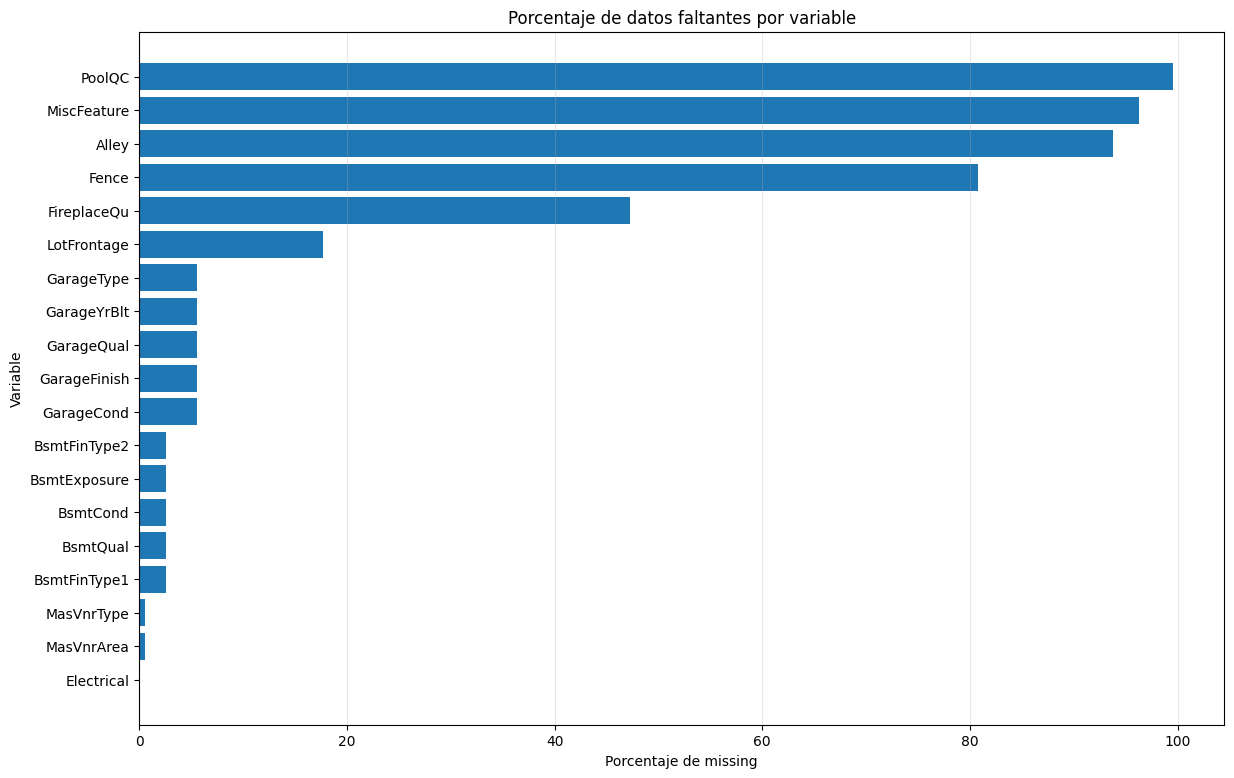

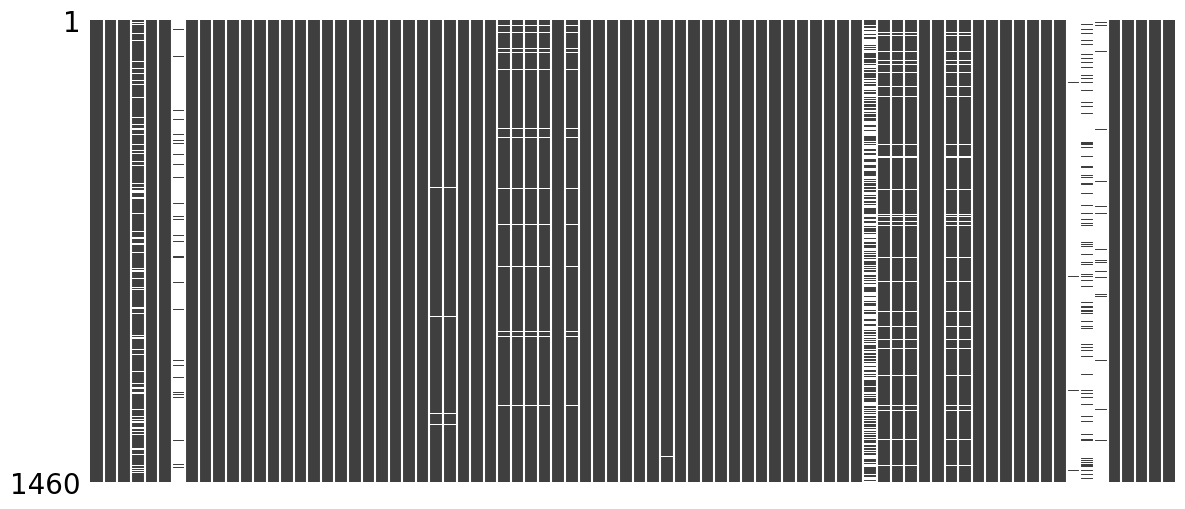

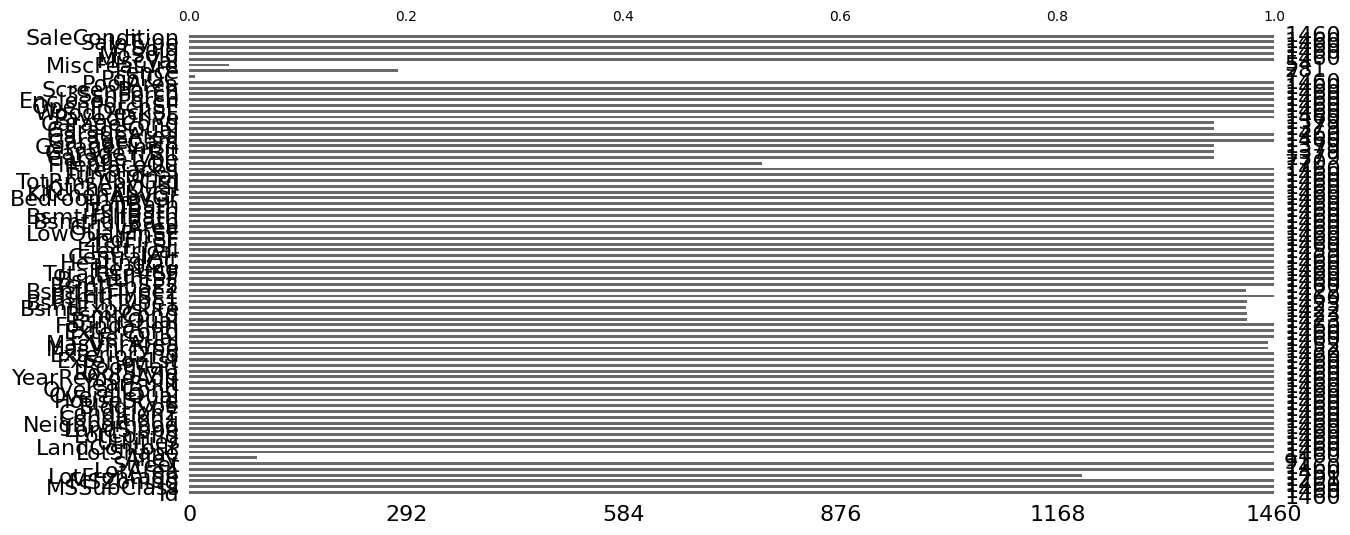

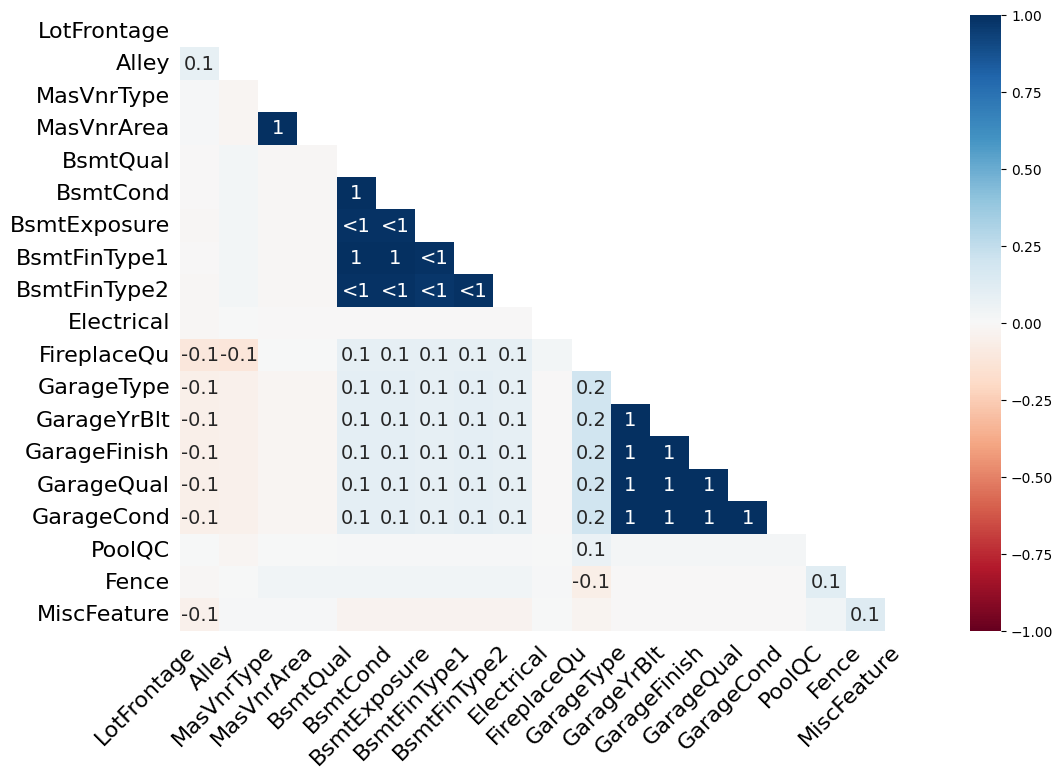


Resumen de faltantes por fila:


,0
count,1460.000000
mean,4.770548
std,1.715177
min,1.000000
25%,4.000000
50%,4.000000
75%,5.000000
max,15.000000


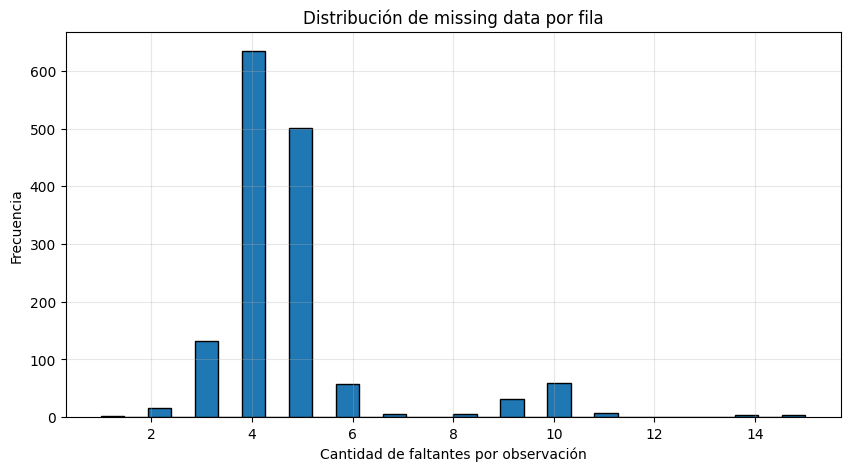


Cantidad de variables numéricas   : 37
Cantidad de variables categóricas : 43
Total de missing en numéricas     : 348
Total de missing en categóricas   : 6617

Variables con más de 5% de faltantes:


,missing_count,missing_pct,dtype
PoolQC,1453,99.520548,object
MiscFeature,1406,96.301370,object
Alley,1369,93.767123,object
Fence,1179,80.753425,object
FireplaceQu,690,47.260274,object
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,object
GarageYrBlt,81,5.547945,float64
GarageQual,81,5.547945,object
GarageFinish,81,5.547945,object



Candidatas a missing estructural:


,missing_count,missing_pct,dtype
PoolQC,1453,99.520548,object
MiscFeature,1406,96.301370,object
Alley,1369,93.767123,object
Fence,1179,80.753425,object
FireplaceQu,690,47.260274,object
GarageType,81,5.547945,object
GarageFinish,81,5.547945,object
GarageQual,81,5.547945,object
GarageCond,81,5.547945,object
BsmtFinType2,38,2.602740,object



Tabla cruzada: Fireplaces vs missing en FireplaceQu


...

GarageType,False,True,All
GarageCars,,,
0,0,81,81
1,369,0,369
2,824,0,824
3,181,0,181
4,5,0,5
All,1379,81,1460



Faltantes restantes luego del tratamiento interpretativo parcial:


,0
LotFrontage,259
Electrical,1



Resultados — Estrategia ingenua
RMSE: 29786.47
MAE : 19093.38
R2  : 0.8843

Resultados — Estrategia interpretativa
RMSE: 29751.5
MAE : 19140.41
R2  : 0.8846

Comparación de estrategias:


,Estrategia,RMSE,MAE,R2
0,Ingenua,29786.470159,19093.375812,0.884329
1,Interpretativa,29751.502463,19140.407073,0.884600


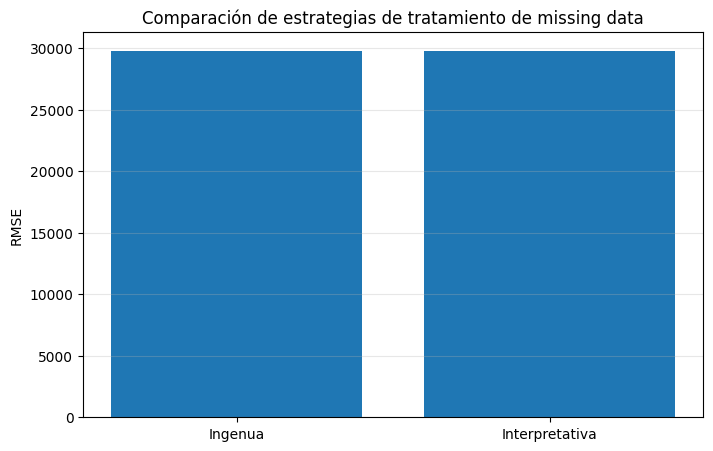


Dimensiones originales: (1460, 80)
Dimensiones con flags : (1460, 99)

Resultados — Estrategia con flags de missing
RMSE: 30049.59
MAE : 18780.28
R2  : 0.8823

Comparación ampliada:


,Estrategia,RMSE,MAE,R2
0,Ingenua,29786.470159,19093.375812,0.884329
1,Interpretativa,29751.502463,19140.407073,0.884600
2,Con flags de missing,30049.590092,18780.279565,0.882276


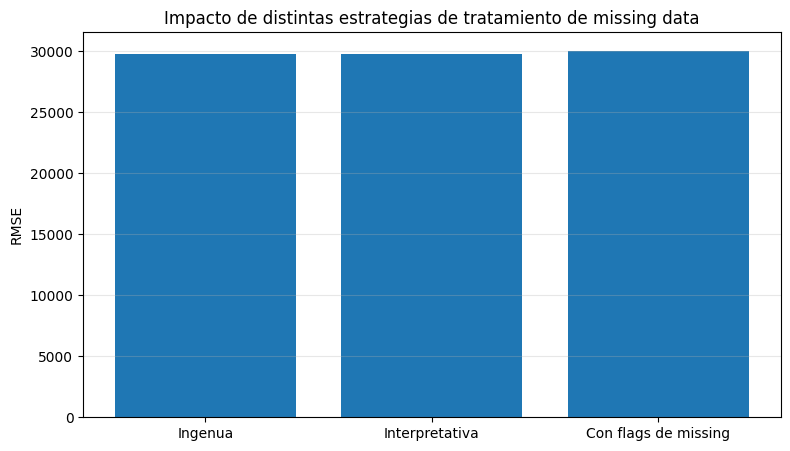

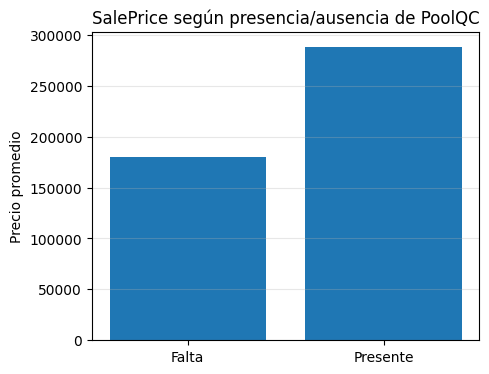

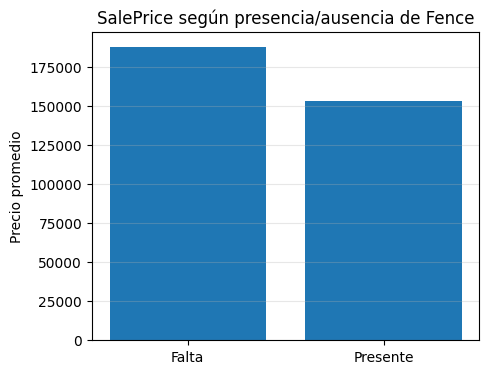

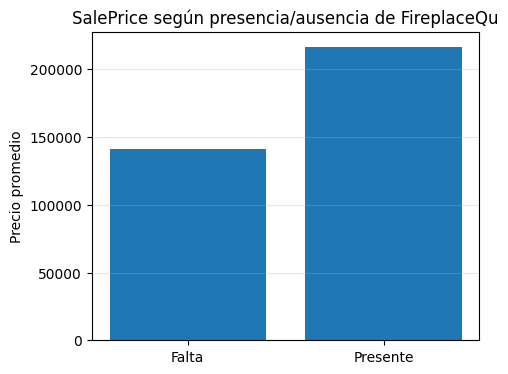

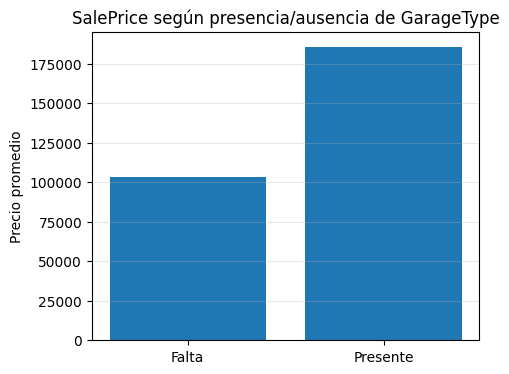

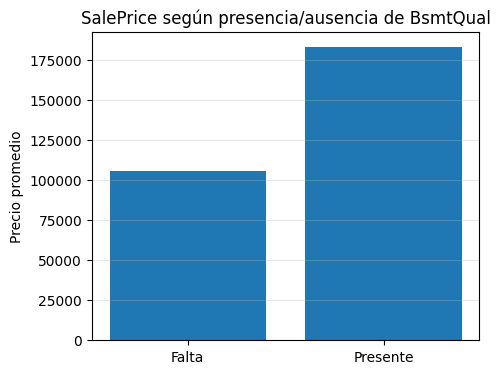

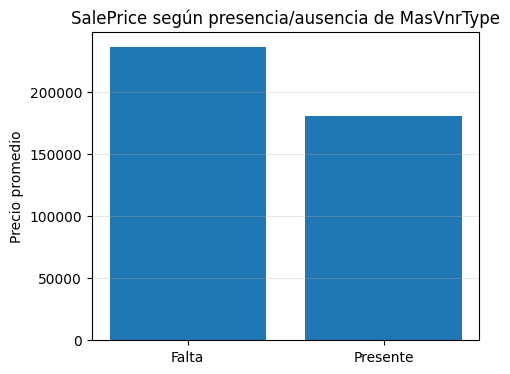


Resultados — Random Forest con estrategia interpretativa
RMSE: 29179.86
MAE : 17595.17
R2  : 0.889

Resumen final:


,Modelo / estrategia,RMSE,MAE,R2
3,Random Forest - Interpretativa,29179.864283,17595.169167,0.888992
1,Ridge - Interpretativa,29751.502463,19140.407073,0.884600
0,Ridge - Ingenua,29786.470159,19093.375812,0.884329
2,Ridge - Con flags,30049.590092,18780.279565,0.882276



Resumen auxiliar de missing data:


,tipo,missing_count,missing_pct,n_unique
PoolQC,object,1453,99.520548,3
MiscFeature,object,1406,96.301370,4
Alley,object,1369,93.767123,2
Fence,object,1179,80.753425,4
FireplaceQu,object,690,47.260274,5
LotFrontage,float64,259,17.739726,110
GarageFinish,object,81,5.547945,3
GarageQual,object,81,5.547945,5
GarageYrBlt,float64,81,5.547945,97
GarageType,object,81,5.547945,6


Variable: PoolQC
Tipo: object
Cantidad de missing: 1453
Porcentaje de missing: 99.52 %
Valores más frecuentes:
PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

Variable: MiscFeature
Tipo: object
Cantidad de missing: 1406
Porcentaje de missing: 96.3 %
Valores más frecuentes:
MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

Variable: Alley
Tipo: object
Cantidad de missing: 1369
Porcentaje de missing: 93.77 %
Valores más frecuentes:
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Variable: Fence
Tipo: object
Cantidad de missing: 1179
Porcentaje de missing: 80.75 %
Valores más frecuentes:
Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

Variable: FireplaceQu
Tipo: object
Cantidad de missing: 690
Porcentaje de missing: 47.26 %
Valores más frecuentes:
FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20


In [5]:
# ============================================================
# MISSING DATA EN HOUSE PRICES (sin subir CSV ni usar Kaggle)
# Bloque único para Google Colab usando OpenML
# ============================================================

# -----------------------------
# 1. Instalación de librerías
# -----------------------------
!pip -q install missingno openml scikit-learn

# -----------------------------
# 2. Importación de librerías
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 3. Descargar dataset desde OpenML
# -----------------------------
# Se descarga el dataset "house_prices" en formato DataFrame
dataset = fetch_openml(name="house_prices", as_frame=True)
df = dataset.frame.copy()

print("Nombre del dataset:", dataset.details.get("name", "house_prices"))
print("Dimensiones del dataset:", df.shape)

# -----------------------------
# 4. Vista inicial del dataset
# -----------------------------
print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nDescripción resumida:")
display(df.describe(include="all").T.head(20))

# -----------------------------
# 5. Separar variable objetivo
# -----------------------------
target = "SalePrice"
X = df.drop(columns=[target]).copy()
y = pd.to_numeric(df[target], errors="coerce").copy()

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# -----------------------------
# 6. Cuantificación global de missing data
# -----------------------------
total_missing = X.isna().sum().sum()
total_cells = X.shape[0] * X.shape[1]
pct_missing = total_missing / total_cells * 100

print(f"\nTotal de valores faltantes: {total_missing}")
print(f"Total de celdas del dataset: {total_cells}")
print(f"Porcentaje global de missing data: {pct_missing:.2f}%")

# -----------------------------
# 7. Missing data por variable
# -----------------------------
missing_by_col = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_pct": X.isna().mean() * 100,
    "dtype": X.dtypes.astype(str)
}).sort_values("missing_pct", ascending=False)

print("\nVariables con faltantes:")
display(missing_by_col[missing_by_col["missing_count"] > 0].head(30))

# -----------------------------
# 8. Gráfico de porcentaje de faltantes por variable
# -----------------------------
plot_data = missing_by_col[missing_by_col["missing_count"] > 0].copy()

plt.figure(figsize=(14, 9))
plt.barh(plot_data.index[::-1], plot_data["missing_pct"][::-1])
plt.xlabel("Porcentaje de missing")
plt.ylabel("Variable")
plt.title("Porcentaje de datos faltantes por variable")
plt.grid(axis="x", alpha=0.3)
plt.show()

# -----------------------------
# 9. Matriz global de missing data
# -----------------------------
msno.matrix(X, figsize=(14, 6), sparkline=False)
plt.show()

# -----------------------------
# 10. Gráfico de barras de completitud
# -----------------------------
msno.bar(X, figsize=(14, 6))
plt.show()

# -----------------------------
# 11. Correlación entre patrones de ausencia
# -----------------------------
msno.heatmap(X, figsize=(12, 8))
plt.show()

# -----------------------------
# 12. Faltantes por observación
# -----------------------------
row_missing = X.isna().sum(axis=1)

print("\nResumen de faltantes por fila:")
display(row_missing.describe())

plt.figure(figsize=(10, 5))
plt.hist(row_missing, bins=30, edgecolor="black")
plt.xlabel("Cantidad de faltantes por observación")
plt.ylabel("Frecuencia")
plt.title("Distribución de missing data por fila")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# 13. Separar variables numéricas y categóricas
# -----------------------------
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

missing_num = X[num_cols].isna().sum().sum()
missing_cat = X[cat_cols].isna().sum().sum()

print("\nCantidad de variables numéricas   :", len(num_cols))
print("Cantidad de variables categóricas :", len(cat_cols))
print("Total de missing en numéricas     :", missing_num)
print("Total de missing en categóricas   :", missing_cat)

# -----------------------------
# 14. Variables con alto nivel de faltantes
# -----------------------------
print("\nVariables con más de 5% de faltantes:")
display(missing_by_col[missing_by_col["missing_pct"] > 5])

# -----------------------------
# 15. Candidatas a missing estructural
# -----------------------------
structural_missing_candidates = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

existing_candidates = [c for c in structural_missing_candidates if c in X.columns]

print("\nCandidatas a missing estructural:")
if existing_candidates:
    display(missing_by_col.loc[existing_candidates].sort_values("missing_pct", ascending=False))

# -----------------------------
# 16. Ejemplo conceptual: chimenea
# -----------------------------
if "Fireplaces" in X.columns and "FireplaceQu" in X.columns:
    print("\nTabla cruzada: Fireplaces vs missing en FireplaceQu")
    table_fp = pd.crosstab(
        X["Fireplaces"].fillna(-1),
        X["FireplaceQu"].isna(),
        margins=True
    )
    display(table_fp)

# -----------------------------
# 17. Ejemplo conceptual: garaje
# -----------------------------
garage_cols = [c for c in X.columns if "Garage" in c]

if garage_cols:
    print("\nPorcentaje de missing en variables de garaje:")
    display(X[garage_cols].isna().mean().sort_values(ascending=False) * 100)

if "GarageCars" in X.columns and "GarageType" in X.columns:
    print("\nTabla cruzada: GarageCars vs missing en GarageType")
    table_garage = pd.crosstab(
        X["GarageCars"].fillna(-1),
        X["GarageType"].isna(),
        margins=True
    )
    display(table_garage)

# -----------------------------
# 18. Preparar dos versiones de la base
# -----------------------------
X_baseline = X.copy()
X_interpret = X.copy()

# -----------------------------
# 19. Tratamiento interpretativo de faltantes categóricos estructurales
# -----------------------------
cat_none_fill = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

for col in cat_none_fill:
    if col in X_interpret.columns:
        X_interpret[col] = X_interpret[col].fillna("None")

# -----------------------------
# 20. Tratamiento interpretativo de faltantes numéricos estructurales
# -----------------------------
num_zero_fill = [
    "MasVnrArea",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath",
    "GarageYrBlt", "GarageCars", "GarageArea"
]

for col in num_zero_fill:
    if col in X_interpret.columns:
        X_interpret[col] = X_interpret[col].fillna(0)

# -----------------------------
# 21. Verificar faltantes restantes luego del tratamiento parcial
# -----------------------------
remaining_missing = X_interpret.isna().sum().sort_values(ascending=False)

print("\nFaltantes restantes luego del tratamiento interpretativo parcial:")
display(remaining_missing[remaining_missing > 0].head(30))

# -----------------------------
# 22. Separar en train y validación
# -----------------------------
X_train_base, X_valid_base, y_train, y_valid = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

X_train_int, X_valid_int, _, _ = train_test_split(
    X_interpret, y, test_size=0.2, random_state=42
)

# -----------------------------
# 23. Pipeline de la estrategia ingenua
# -----------------------------
num_cols_base = X_train_base.select_dtypes(include=["number"]).columns.tolist()
cat_cols_base = X_train_base.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_base = ColumnTransformer(transformers=[
    ("num", numeric_transformer_base, num_cols_base),
    ("cat", categorical_transformer_base, cat_cols_base)
])

model_base = Pipeline(steps=[
    ("preprocessor", preprocessor_base),
    ("model", Ridge(alpha=1.0))
])

# -----------------------------
# 24. Entrenar y evaluar estrategia ingenua
# -----------------------------
model_base.fit(X_train_base, y_train)
pred_base = model_base.predict(X_valid_base)

rmse_base = mean_squared_error(y_valid, pred_base) ** 0.5
mae_base = mean_absolute_error(y_valid, pred_base)
r2_base = r2_score(y_valid, pred_base)

print("\nResultados — Estrategia ingenua")
print("RMSE:", round(rmse_base, 2))
print("MAE :", round(mae_base, 2))
print("R2  :", round(r2_base, 4))

# -----------------------------
# 25. Pipeline de la estrategia interpretativa
# -----------------------------
num_cols_int = X_train_int.select_dtypes(include=["number"]).columns.tolist()
cat_cols_int = X_train_int.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer_int = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_int = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_int = ColumnTransformer(transformers=[
    ("num", numeric_transformer_int, num_cols_int),
    ("cat", categorical_transformer_int, cat_cols_int)
])

model_int = Pipeline(steps=[
    ("preprocessor", preprocessor_int),
    ("model", Ridge(alpha=1.0))
])

# -----------------------------
# 26. Entrenar y evaluar estrategia interpretativa
# -----------------------------
model_int.fit(X_train_int, y_train)
pred_int = model_int.predict(X_valid_int)

rmse_int = mean_squared_error(y_valid, pred_int) ** 0.5
mae_int = mean_absolute_error(y_valid, pred_int)
r2_int = r2_score(y_valid, pred_int)

print("\nResultados — Estrategia interpretativa")
print("RMSE:", round(rmse_int, 2))
print("MAE :", round(mae_int, 2))
print("R2  :", round(r2_int, 4))

# -----------------------------
# 27. Comparar ambas estrategias
# -----------------------------
results = pd.DataFrame({
    "Estrategia": ["Ingenua", "Interpretativa"],
    "RMSE": [rmse_base, rmse_int],
    "MAE": [mae_base, mae_int],
    "R2": [r2_base, r2_int]
})

print("\nComparación de estrategias:")
display(results)

plt.figure(figsize=(8, 5))
plt.bar(results["Estrategia"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Comparación de estrategias de tratamiento de missing data")
plt.grid(axis="y", alpha=0.3)
plt.show()

# -----------------------------
# 28. Crear flags de missing
# -----------------------------
X_flag = X.copy()

important_missing_cols = [c for c in X.columns if X[c].isna().sum() > 0]

for col in important_missing_cols:
    X_flag[col + "_was_missing"] = X_flag[col].isna().astype(int)

print("\nDimensiones originales:", X.shape)
print("Dimensiones con flags :", X_flag.shape)

# -----------------------------
# 29. Entrenar modelo con flags de missing
# -----------------------------
X_train_flag, X_valid_flag, y_train_flag, y_valid_flag = train_test_split(
    X_flag, y, test_size=0.2, random_state=42
)

num_cols_flag = X_train_flag.select_dtypes(include=["number"]).columns.tolist()
cat_cols_flag = X_train_flag.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer_flag = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_flag = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_flag = ColumnTransformer(transformers=[
    ("num", numeric_transformer_flag, num_cols_flag),
    ("cat", categorical_transformer_flag, cat_cols_flag)
])

model_flag = Pipeline(steps=[
    ("preprocessor", preprocessor_flag),
    ("model", Ridge(alpha=1.0))
])

model_flag.fit(X_train_flag, y_train_flag)
pred_flag = model_flag.predict(X_valid_flag)

rmse_flag = mean_squared_error(y_valid_flag, pred_flag) ** 0.5
mae_flag = mean_absolute_error(y_valid_flag, pred_flag)
r2_flag = r2_score(y_valid_flag, pred_flag)

print("\nResultados — Estrategia con flags de missing")
print("RMSE:", round(rmse_flag, 2))
print("MAE :", round(mae_flag, 2))
print("R2  :", round(r2_flag, 4))

# -----------------------------
# 30. Comparación ampliada
# -----------------------------
results2 = pd.DataFrame({
    "Estrategia": ["Ingenua", "Interpretativa", "Con flags de missing"],
    "RMSE": [rmse_base, rmse_int, rmse_flag],
    "MAE": [mae_base, mae_int, mae_flag],
    "R2": [r2_base, r2_int, r2_flag]
})

print("\nComparación ampliada:")
display(results2)

plt.figure(figsize=(9, 5))
plt.bar(results2["Estrategia"], results2["RMSE"])
plt.ylabel("RMSE")
plt.title("Impacto de distintas estrategias de tratamiento de missing data")
plt.grid(axis="y", alpha=0.3)
plt.show()

# -----------------------------
# 31. Analizar si la ausencia se relaciona con SalePrice
# -----------------------------
candidate_cols = ["PoolQC", "Fence", "FireplaceQu", "GarageType", "BsmtQual", "MasVnrType"]
candidate_cols = [c for c in candidate_cols if c in df.columns]

for col in candidate_cols:
    tmp = df[[col, "SalePrice"]].copy()
    tmp["SalePrice"] = pd.to_numeric(tmp["SalePrice"], errors="coerce")
    tmp["missing"] = tmp[col].isna().map({True: "Falta", False: "Presente"})
    groups = tmp.groupby("missing")["SalePrice"].mean()

    plt.figure(figsize=(5, 4))
    plt.bar(groups.index, groups.values)
    plt.ylabel("Precio promedio")
    plt.title(f"SalePrice según presencia/ausencia de {col}")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# -----------------------------
# 32. Comparar con Random Forest
# -----------------------------
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_int),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train_int, y_train)
pred_rf = rf_model.predict(X_valid_int)

rmse_rf = mean_squared_error(y_valid, pred_rf) ** 0.5
mae_rf = mean_absolute_error(y_valid, pred_rf)
r2_rf = r2_score(y_valid, pred_rf)

print("\nResultados — Random Forest con estrategia interpretativa")
print("RMSE:", round(rmse_rf, 2))
print("MAE :", round(mae_rf, 2))
print("R2  :", round(r2_rf, 4))

# -----------------------------
# 33. Cuadro resumen final
# -----------------------------
final_results = pd.DataFrame({
    "Modelo / estrategia": [
        "Ridge - Ingenua",
        "Ridge - Interpretativa",
        "Ridge - Con flags",
        "Random Forest - Interpretativa"
    ],
    "RMSE": [rmse_base, rmse_int, rmse_flag, rmse_rf],
    "MAE": [mae_base, mae_int, mae_flag, mae_rf],
    "R2": [r2_base, r2_int, r2_flag, r2_rf]
}).sort_values("RMSE")

print("\nResumen final:")
display(final_results)

# -----------------------------
# 34. Función auxiliar para resumir missing data
# -----------------------------
def resumen_missing(df_):
    summary = pd.DataFrame({
        "tipo": df_.dtypes.astype(str),
        "missing_count": df_.isna().sum(),
        "missing_pct": df_.isna().mean() * 100,
        "n_unique": df_.nunique(dropna=True)
    }).sort_values("missing_pct", ascending=False)
    return summary

print("\nResumen auxiliar de missing data:")
display(resumen_missing(df).head(30))

# -----------------------------
# 35. Explorar rápidamente variables con faltantes
# -----------------------------
summary = resumen_missing(df)
top_missing_vars = summary[summary["missing_count"] > 0].head(10).index.tolist()

for col in top_missing_vars:
    print("=" * 80)
    print("Variable:", col)
    print("Tipo:", df[col].dtype)
    print("Cantidad de missing:", df[col].isna().sum())
    print("Porcentaje de missing:", round(df[col].isna().mean() * 100, 2), "%")
    print("Valores más frecuentes:")
    print(df[col].value_counts(dropna=False).head(10))
    print()